In [1]:
# Notebook to plot the track recontruction for different radii to fild the best one

import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D 
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors 
# import plotly.express as px
# import plotly.io as pio

import sys
sys.path.append("../scripts")
from TrackReconstruction_functions import *
from reconstruction_functions import *



In [2]:
diff = "5percent"
pressure = 1

# Set the detector size depending on the pressure
density = 5.987*pressure
M = 1000/0.9
det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0
print(det_size)


def LoadMeta(name, reco_mode):
    meta = pd.read_hdf(f"../data/TrackRecoOptimization/ATPC_{name}_{pressure}bar_{diff}_reco{reco_mode}.h5", "meta")
    meta["Type"] = name
    meta["reco_mode"] = reco_mode
    meta = meta[meta.primary == 1]
    return meta

nubb = []
Bi = []
Tl = []
Single=[]

for i in np.arange(1,7,1):
    nubb.append(LoadMeta("0nubb", i))
    Bi.append(LoadMeta("Bi_ion", i))
    Tl.append(LoadMeta("Tl_ion", i))
    Single.append(LoadMeta("single", i))

nubb = pd.concat(nubb)
Bi = pd.concat(Bi)
Tl = pd.concat(Tl)
Single = pd.concat(Single)

Bkgs = pd.concat([Bi, Tl, Single])

display(Bkgs)


3091.169274839764


,event_id,trkID,primary,start,end,length,energy,blob1,blob2,blob1R,...,blob1RTD,blob2RTD,Tortuosity1,Tortuosity2,Squiglicity1,Squiglicity2,label,contained,Type,reco_mode
0,30060000000,0,1,0,15,3128.635,2.076637,0.287990,0.087358,0.342078,...,0.342078,0.092400,2.370710,1.076644,1.391079e+00,3.114073e-01,Primary,True,Bi_ion,1
0,30060000001,0,1,0,1,16.318,2.461797,2.301725,0.160072,2.301725,...,2.301725,0.160072,1.000000,1.000000,5.328078e-14,5.328078e-14,Primary,False,Bi_ion,1
0,30060000003,0,1,29,130,3427.272,2.135772,0.378775,0.069616,0.401417,...,0.401417,0.069616,1.611594,1.032528,9.484594e-01,1.856251e-01,Primary,True,Bi_ion,1
0,30060000005,0,1,1,12,96.000,2.436724,0.827502,0.001736,0.827502,...,0.827502,0.001736,1.897367,1.897367,1.387286e+00,1.387286e+00,Primary,False,Bi_ion,1
0,30060000006,0,1,115,142,3737.544,2.429486,0.206684,0.048917,0.357949,...,0.357949,0.048917,4.517757,1.035887,2.155774e+00,1.516905e-01,Primary,True,Bi_ion,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,1723235,0,1,0,70,3095.789,1.907036,0.700599,0.288056,1.158744,...,1.561660,0.368782,2.519280,1.086653,1.642640e+00,3.526760e-01,Primary,False,single,6
0,1723260,0,1,4,99,3718.500,2.446421,0.573468,0.388485,0.932010,...,0.932010,0.577608,1.626323,1.048479,7.858989e-01,2.512014e-01,Primary,True,single,6
0,1723264,0,1,13,108,4043.023,2.440737,0.704193,0.306977,1.103171,...,1.103171,0.322675,1.627903,1.024392,9.053583e-01,1.764386e-01,Primary,True,single,6
0,1723267,0,1,59,176,3453.927,2.213169,0.684730,0.269807,1.127169,...,1.245191,0.294160,2.214072,1.037141,1.749660e+00,2.411618e-01,Primary,True,single,6


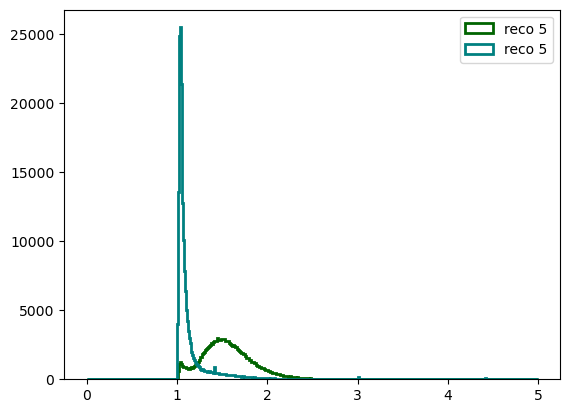

In [19]:
plt.figure()

# for i in np.arange(1,7,1):
i=5
plt.hist(nubb[nubb.reco_mode == i].Tortuosity2, bins = np.arange(0, 5, 0.01), histtype = "step", linewidth = 2, label = f"reco {i}", color = "darkgreen")
plt.hist(Bi[Bi.reco_mode == i].Tortuosity2, bins = np.arange(0, 5, 0.01), histtype = "step", linewidth = 2, label = f"reco {i}", color = "Teal")

plt.legend()

In [21]:
# Make a plot of the ratio of signal efficiency vs background efficiency vs blob energy

def ScanCut(label, range_min, range_max):

    Rs_all  = []
    Es_all  = []

    for i in np.arange(1,7,1):
        Rs = []
        Es = []
        for E in np.linspace(range_min, range_max, 100):
            nubb_cut = nubb[ (nubb.reco_mode == i) & (nubb[label] > E)]
            Bkgs_cut = Bkgs[ (Bkgs.reco_mode == i) & (Bkgs[label] > E)]
            R = len(nubb_cut)/len(Bkgs_cut)
            Rs.append(R)
            Es.append(E)

        Rs_all.append(Rs)
        Es_all.append(Es)
    return Rs_all, Es_all

Text(0.5, 1.0, 'Blob2')

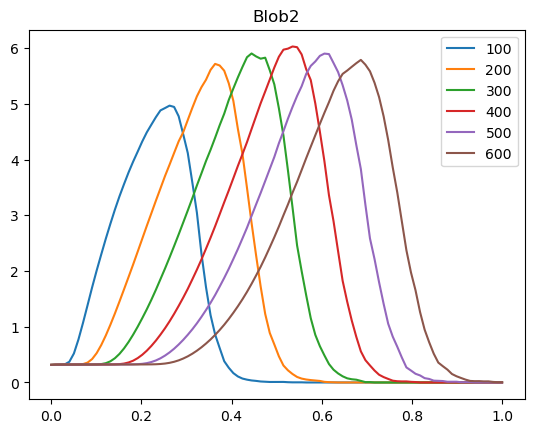

In [24]:
Rs_all, Es_all = ScanCut("blob2", 0, 1)
plt.figure()
for i in np.arange(0,6,1):
    plt.plot(Es_all[i],Rs_all[i],label = 100*(i+1));
plt.legend()
plt.title("Blob2")


Text(0.5, 1.0, 'Blob2R')

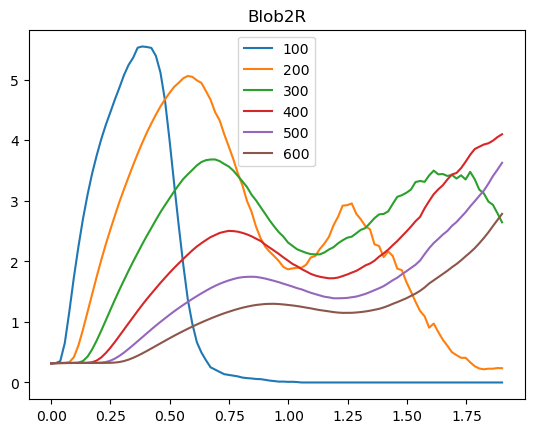

In [25]:
Rs_all, Es_all = ScanCut("blob2R", 0, 1.9)
plt.figure()
for i in np.arange(0,6,1):
    plt.plot(Es_all[i],Rs_all[i],label = 100*(i+1));
plt.legend()
plt.title("Blob2R")

Text(0.5, 1.0, 'Tortuosity2')

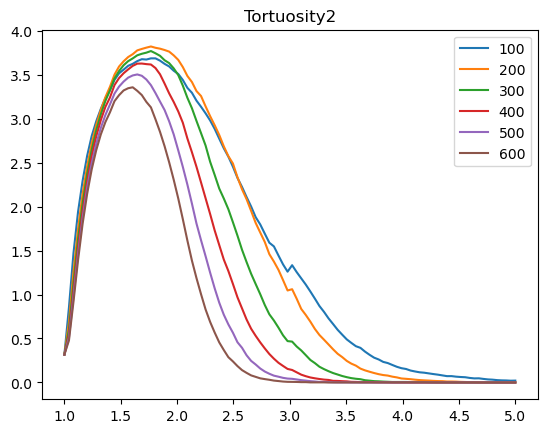

In [26]:
Rs_all, Es_all = ScanCut("Tortuosity2", 1, 5)
plt.figure()
for i in np.arange(0,6,1):
    plt.plot(Es_all[i],Rs_all[i],label = 100*(i+1));
plt.legend()
plt.title("Tortuosity2")

Text(0.5, 1.0, 'Blob2RTD')

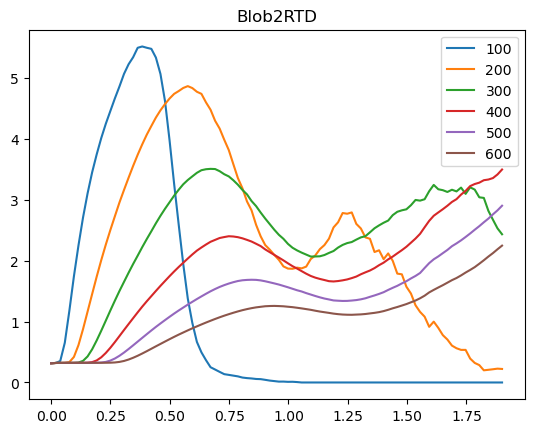

In [27]:
Rs_all, Es_all = ScanCut("blob2RTD", 0, 1.9)
plt.figure()
for i in np.arange(0,6,1):
    plt.plot(Es_all[i],Rs_all[i],label = 100*(i+1));
plt.legend()
plt.title("Blob2RTD")

Text(0.5, 1.0, 'Squiglicity2')

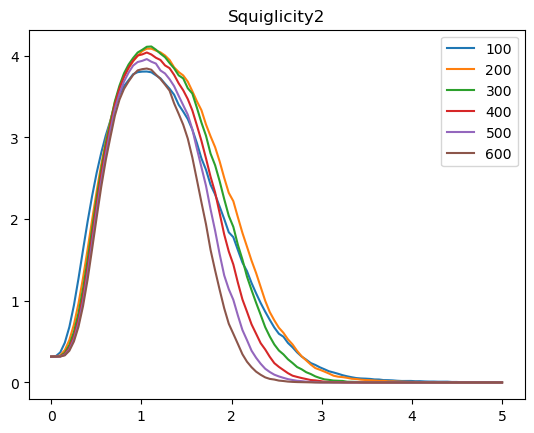

In [29]:
Rs_all, Es_all = ScanCut("Squiglicity2", 0, 5)
plt.figure()
for i in np.arange(0,6,1):
    plt.plot(Es_all[i],Rs_all[i],label = 100*(i+1));
plt.legend()
plt.title("Squiglicity2")